In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2025, 11, 1)

df = yf.download(stock, start, end)


[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,
2007-10-05,30.896225,33.629589,25.536989,27.579334,855215656
2007-10-08,29.314564,31.940436,29.130291,31.940436,126671715
2007-10-09,31.310843,31.587249,27.748255,29.329920,116725709
2007-10-10,31.602608,32.247560,31.326201,32.124711,67931378
2007-10-11,35.134491,36.854362,31.326209,36.854362,106320954


In [4]:
df.shape

(4456, 5)

In [5]:
df.isnull().sum()

Price   Ticker      
Close   POWERGRID.NS    0
High    POWERGRID.NS    0
Low     POWERGRID.NS    0
Open    POWERGRID.NS    0
Volume  POWERGRID.NS    0
dtype: int64

In [6]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4456.000000,4456.000000,4456.000000,4456.000000,4.456000e+03
mean,87.693879,88.806668,86.602167,87.736672,1.192450e+07
std,76.827342,77.695186,75.946867,76.833652,2.008864e+07
min,18.038853,19.282911,16.172765,19.189606,0.000000e+00
25%,35.047287,35.609094,34.608276,35.115928,4.944299e+06
50%,63.998329,65.033185,63.146765,63.920826,8.562503e+06
75%,97.150391,98.715712,95.584976,97.545917,1.378440e+07
max,344.843262,345.598137,337.058457,343.522181,8.552157e+08


In [7]:
df = df.reset_index()

In [8]:
df.columns

MultiIndex([(  'Date',             ''),
            ( 'Close', 'POWERGRID.NS'),
            (  'High', 'POWERGRID.NS'),
            (   'Low', 'POWERGRID.NS'),
            (  'Open', 'POWERGRID.NS'),
            ('Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [9]:
df.to_csv("powergrid.csv")

In [10]:
data01 = pd.read_csv("powergrid.csv")

In [11]:
data01.head()

,Price,Date,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,30.896224975585938,33.62958943855421,25.53698869452309,27.579334367613164,855215656
2,1,2007-10-08,29.314563751220703,31.940435853510763,29.130291220861363,31.940435853510763,126671715
3,2,2007-10-09,31.310842514038086,31.58724924482206,27.748255301780677,29.329919973198724,116725709
4,3,2007-10-10,31.60260772705078,32.247559585247785,31.326200977987867,32.124710521273876,67931378


In [12]:
# Candlesticks 
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(x = data01['Date'], open = data01['Open'], 
                                    high = data01['High'],
                                    low = data01['Low'], 
                                    close = data01['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

In [13]:
df = df.drop(['Date'], axis = 1)

C:\Users\USER\AppData\Local\Temp\ipykernel_14732\1002300862.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date'], axis = 1)


In [14]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,30.896225,33.629589,25.536989,27.579334,855215656
1,29.314564,31.940436,29.130291,31.940436,126671715
2,31.310843,31.587249,27.748255,29.329920,116725709
3,31.602608,32.247560,31.326201,32.124711,67931378
4,35.134491,36.854362,31.326209,36.854362,106320954


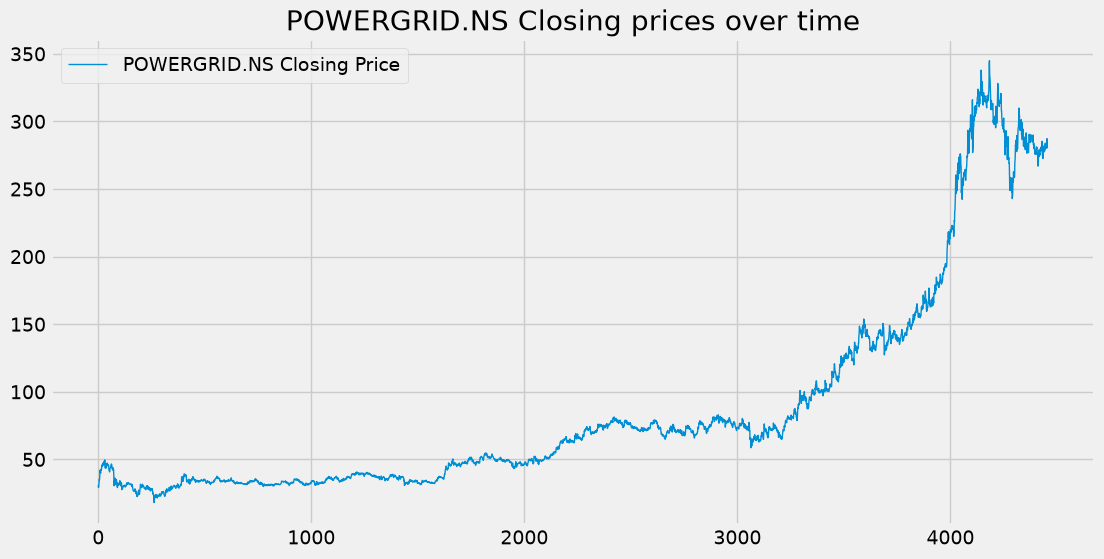

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

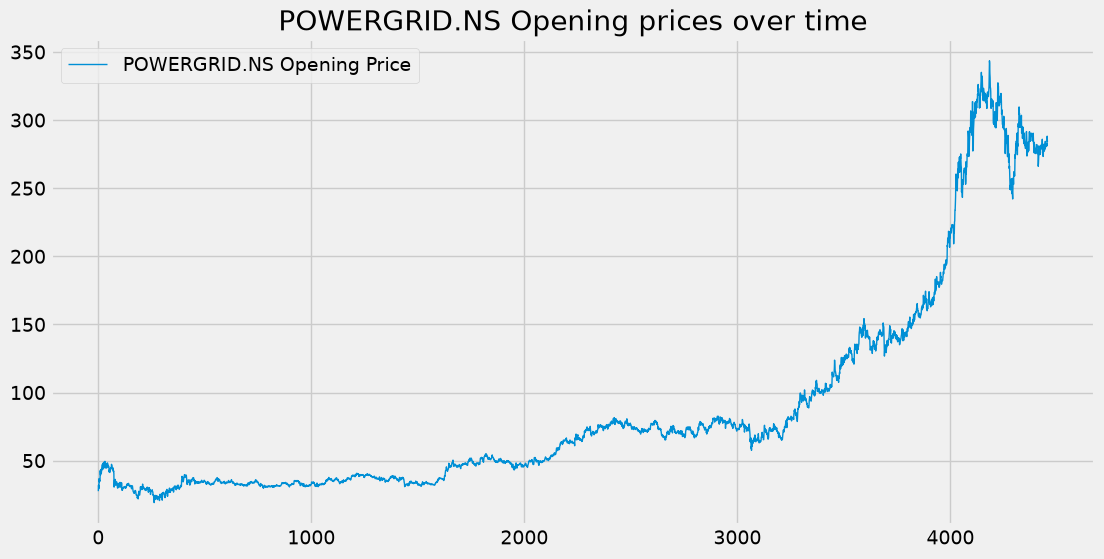

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

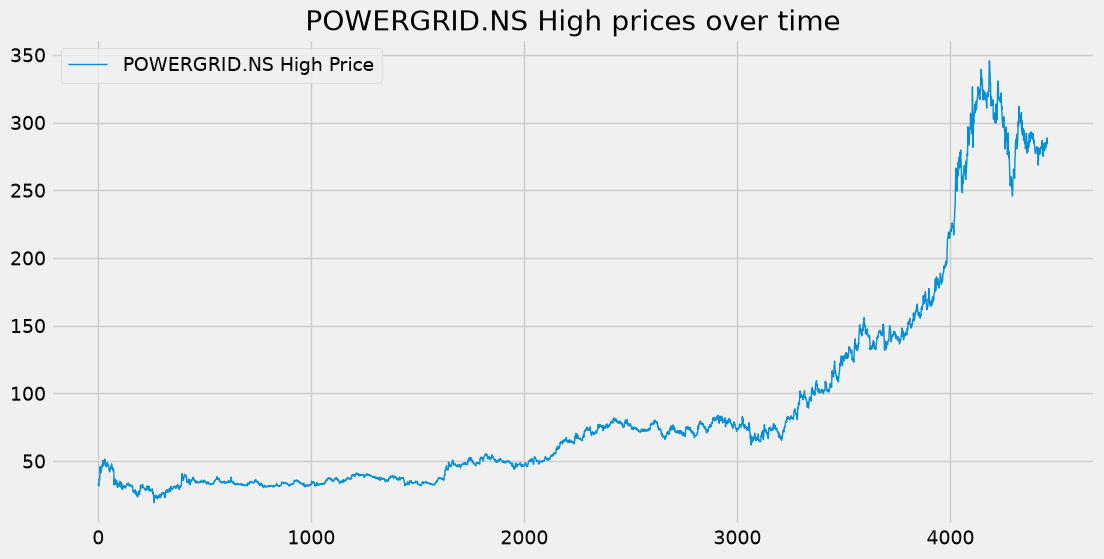

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

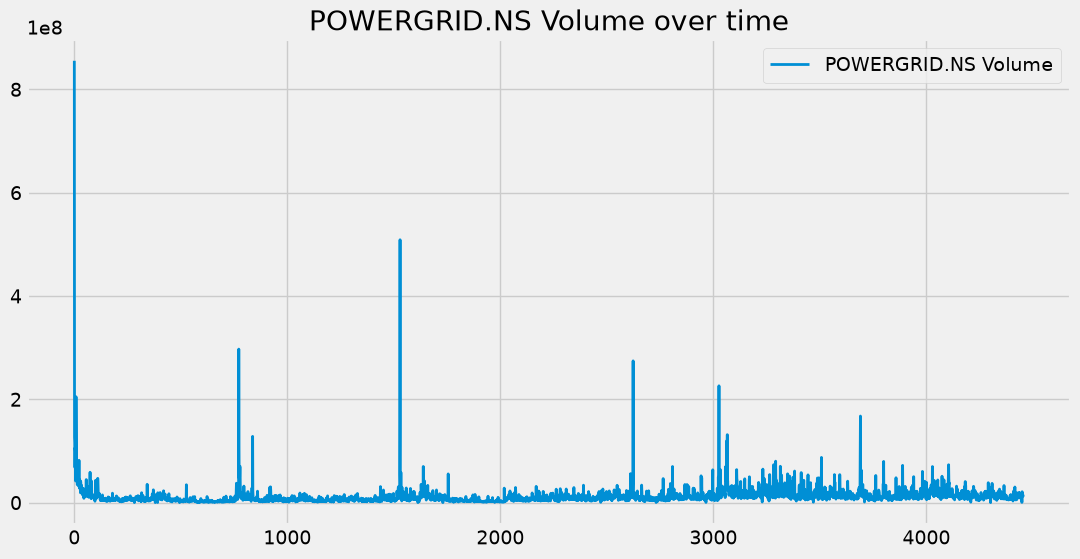

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 2)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [19]:
# Moving Average
# [10, 20, 30, 40, 50, 60, 70, 80, 90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [20]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [21]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [22]:
# calculates the 100-day moving average of POWERGRID's closing price

ma100 = df.Close.rolling(100).mean()

In [23]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4451,280.897657
4452,280.906821
4453,280.929839
4454,280.900405


In [24]:
# calculating a 200-day moving average.

ma200 = df.Close.rolling(200).mean()

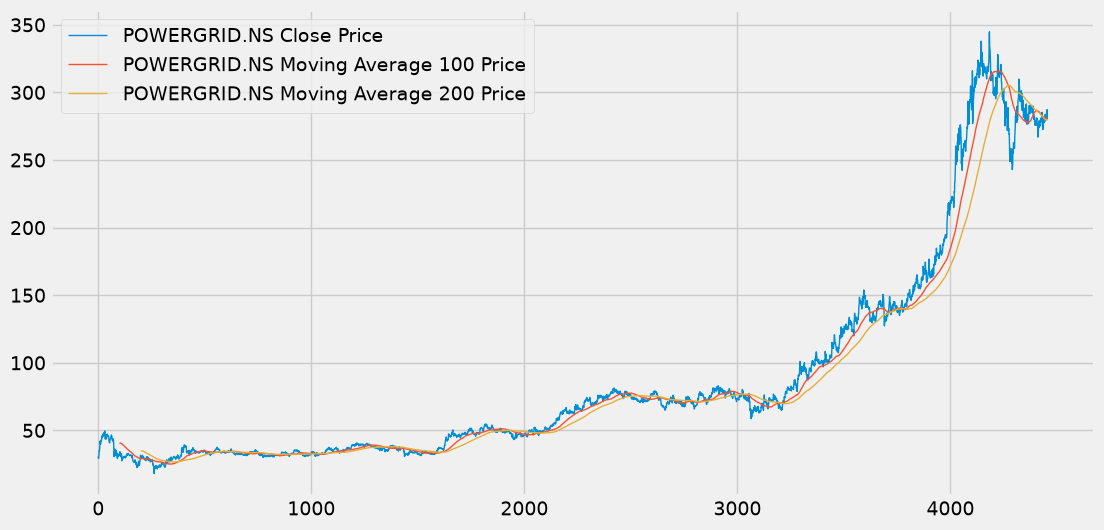

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [26]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [27]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

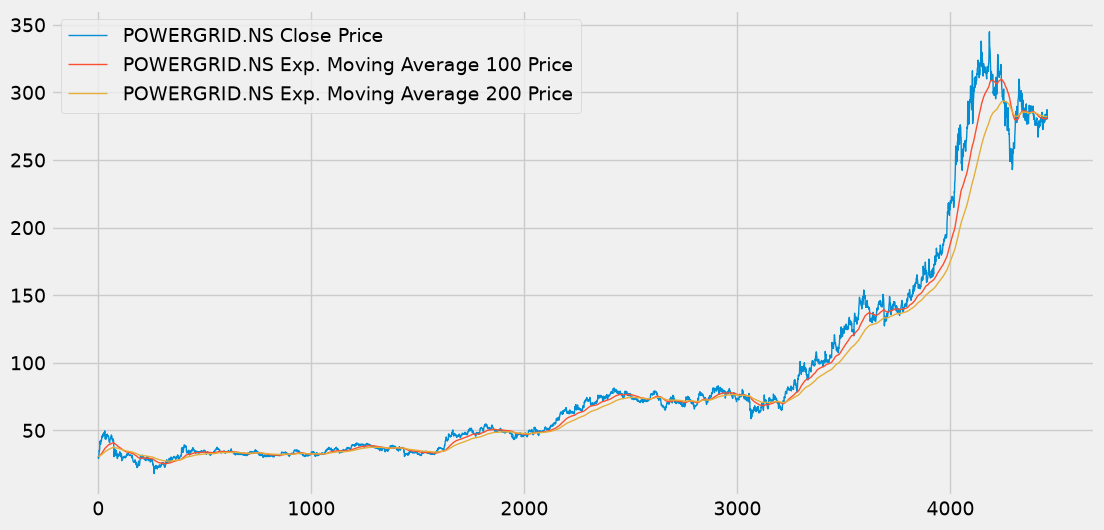

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [29]:
# Training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [30]:
data_training.shape

(3119, 1)

In [31]:
data_testing.shape

(1337, 1)

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))

In [33]:
data_training_array = scaler.fit_transform(data_training)

In [34]:
data_training_array

array([[0.19808584],
       [0.17371813],
       [0.2044736 ],
       ...,
       [0.7906702 ],
       [0.78753772],
       [0.79348979]], shape=(3119, 1))

In [35]:
data_training_array.shape[0]

3119

In [36]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train  = np.array(x_train), np.array(y_train)

In [37]:
x_train.shape

(3019, 100, 1)

In [39]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [40]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

C:\Users\USER\anaconda3\envs\stock_price\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 100, 80)             │          45,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 100, 80)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 120)                 │          96,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 120)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │             121 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 246ms/step - loss: 0.0397
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - loss: 0.0091
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - loss: 0.0076
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 227ms/step - loss: 0.0067
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - loss: 0.0072
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - loss: 0.0062
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - loss: 0.0058
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - loss: 0.0057
Epoch 9/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 232ms/step - loss: 0.0054
Epoch 10/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 229ms/step - loss: 0.0049
Epoch 11/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - loss: 0.0049
Epoch 12/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 223ms/step - loss: 0.0046
Epoch 13/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 226ms/step - loss: 0.0045
Epoch 14/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - loss: 0.0042
Epoch 15/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 

In [43]:
past_100_days = data_training.tail(100)

In [46]:
final_df = pd.concat(
    [past_100_days, data_testing],
    ignore_index=True
)

In [47]:
final_df.head()

Ticker,POWERGRID.NS
0,76.586159
1,76.193901
2,77.056847
3,77.429497
4,80.273254


In [48]:
input_data = scaler.fit_transform(final_df)

In [49]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test  = np.array(x_test), np.array(y_test)

In [50]:
x_test.shape

(1337, 100, 1)

In [51]:
y_predicted = model.predict(x_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step


In [52]:
y_predicted.shape

(1337, 1)

In [53]:
scaler.scale_

array([0.00349382])

In [54]:
scaler_factor = 1 / 0.00349382
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor


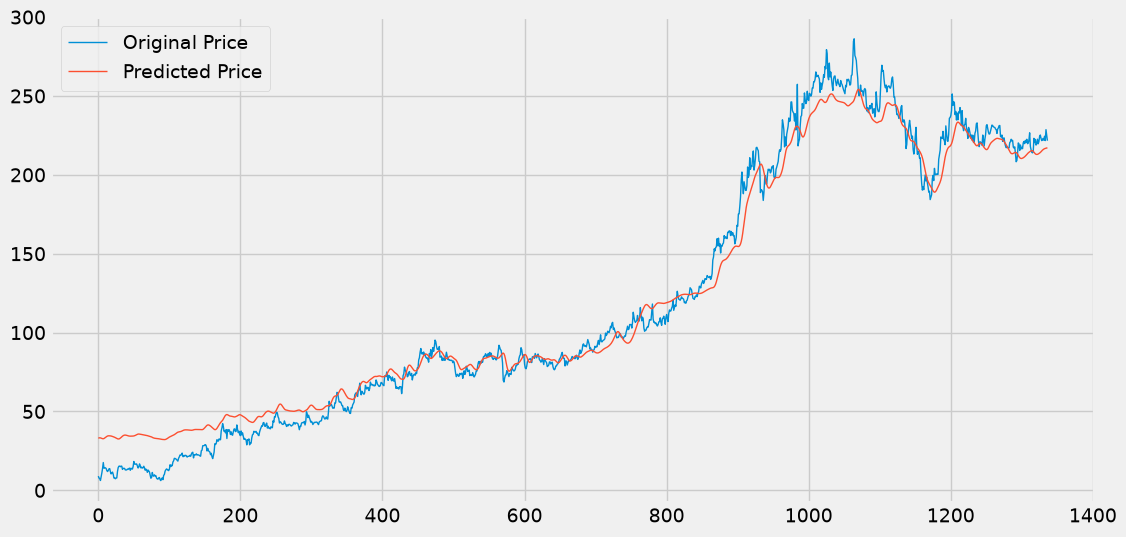

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()


In [56]:
model.save('stock_dl_model.h5')